In [2]:
import pandas as pd

# Creamos datos de ejemplo de sucursales
datos = {
    'Sucursal': ['Mendoza', 'Buenos Aires', 'Córdoba', 'Santa Fe'],
    'Presupuesto_Asignado': [500000, 750000, 450000, 300000],
    'Gasto_Real': [480000, 790000, 410000, 325000]
}

# Transformamos los datos en un DataFrame de Pandas
df = pd.DataFrame(datos)

# Calculamos la columna de desvío
df['Desvío'] = df['Gasto_Real'] - df['Presupuesto_Asignado']

# Mostramos la tabla en pantalla
df


,Sucursal,Presupuesto_Asignado,Gasto_Real,Desvío
0,Mendoza,500000,480000,-20000
1,Buenos Aires,750000,790000,40000
2,Córdoba,450000,410000,-40000
3,Santa Fe,300000,325000,25000


Total Presupuesto General: $2000000
Total Gasto Real General: $2005000



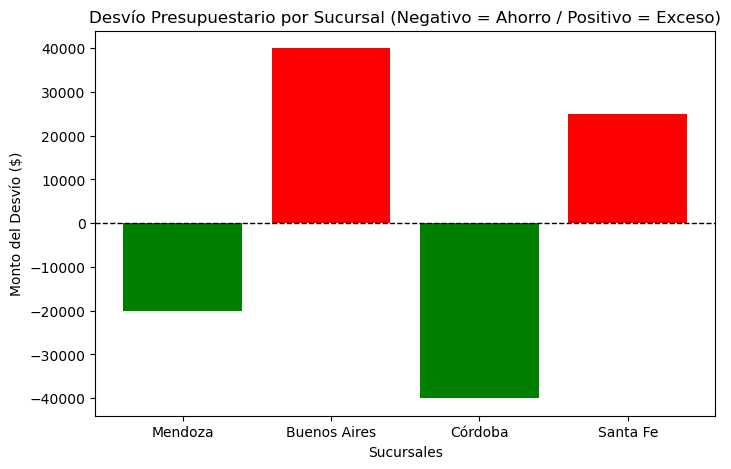

In [3]:
import matplotlib.pyplot as plt

# 1. CALCULAMOS TOTALES (Se muestra en la consola)
total_presupuesto = df['Presupuesto_Asignado'].sum()
total_gasto = df['Gasto_Real'].sum()
print(f"Total Presupuesto General: ${total_presupuesto}")
print(f"Total Gasto Real General: ${total_gasto}\n")

# 2. CREAMOS EL GRÁFICO DE BARRAS
# Definimos el tamaño de la figura (ancho, alto)
plt.figure(figsize=(8, 5))

# Dibujamos las barras usando los nombres de las sucursales y sus desvíos
plt.bar(df['Sucursal'], df['Desvío'], color=['green' if x < 0 else 'red' for x in df['Desvío']])

# Agregamos títulos y etiquetas decorativas al gráfico
plt.title('Desvío Presupuestario por Sucursal (Negativo = Ahorro / Positivo = Exceso)')
plt.xlabel('Sucursales')
plt.ylabel('Monto del Desvío ($)')
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Línea de referencia en cero

# Mostramos el gráfico finalizado en pantalla
plt.show()


In [4]:
# Guardamos el DataFrame actual en un archivo Excel físico
df.to_excel('Reporte_Desvio_Presupuestario.xlsx', index=False)

print("¡Archivo de Excel guardado con éxito!")


¡Archivo de Excel guardado con éxito!


In [5]:
!pip install psycopg2-binary


   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 29.7 MB/s eta 0:00:00


In [6]:
import getpass
import pandas as pd
import psycopg2

# 1. Python te va a pedir la contraseña de forma oculta en un cuadro de texto
clave_bd = getpass.getpass("Ingresá tu contraseña de PostgreSQL y dale Enter: ")

usuario_bd = "postgres"
nombre_bd = "ventas_demo"
host_bd = "localhost"
puerto_bd = "5432"

try:
    conexion = psycopg2.connect(
        user=usuario_bd,
        password=clave_bd,
        host=host_bd,
        port=puerto_bd,
        database=nombre_bd
    )
    
    query_tablas = """
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'public';
    """
    
    tablas_existentes = pd.read_sql(query_tablas, conexion)
    conexion.close()
    
    print("\n¡Conexión exitosa a ventas_demo!")
    print("\nTablas que tenés disponibles para analizar:")
    print(tablas_existentes)

except Exception as e:
    print("\nError al conectar. Revisá la contraseña.")
    print(e)


Ingresá tu contraseña de PostgreSQL y dale Enter:  ········



Error al conectar. Revisá la contraseña.
connection to server at "localhost" (::1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?

